# Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter # fazer contagem de frequência

# Dados

Amostras de valores dizendo se a classe baseada nas variáveis "x1" e "x2" se a pessoa teve o créditoo "negado" ou "aprovado"

In [2]:
df = pd.DataFrame({  "x1": [0.10, 0.20, 0.85, 0.90, 0.75, 0.30, 0.60, 0.40],
    "x2": [0.80, 0.70, 0.20, 0.10, 0.30, 0.60, 0.40, 0.55],
    "classe": ["negado","negado","aprovado","aprovado","aprovado","negado","aprovado","negado"]
 })

In [3]:
df.head(10)

,x1,x2,classe
0,0.10,0.80,negado
1,0.20,0.70,negado
2,0.85,0.20,aprovado
3,0.90,0.10,aprovado
4,0.75,0.30,aprovado
5,0.30,0.60,negado
6,0.60,0.40,aprovado
7,0.40,0.55,negado


# Distância Euclidiana

Distância entre um ponto a e um ponto b e é pelo quadrado da soma.

In [4]:
def euclidean(a, b):
    return np.sqrt(((a - b)**2).sum())

# Aplicação da Função

In [7]:
def knn_predict(df,x_new, k=3):
    # df -> especificar meu dataframe
    # x_new -> o que eu quero visualizar
    # k=3 -> a quantidade de vizinhos máximos que vou calcular
    X_train = df[['x1', 'x2']].values
    y_train = df['classe'].values # variável que quero fazer a predição encima, o que tenho de atributo do outro lado
    dists = np.array([euclidean(x, x_new) for x in X_train]) # distancia entre o ponto dado e o ponto novo 
    idx = np.argsort(dists)[:k] # index do vizinho mais próximo
    votos = Counter(y_train[idx]) # Votação -> qual a classe mais frequente entre os vizinhos
    classe_predits = votos.most_common(1)[0][0]
    return classe_predits

In [8]:
x_new = np.array([0.62, 0.35])
classe = knn_predict(df,x_new)
print(classe)

aprovado


# Visualização

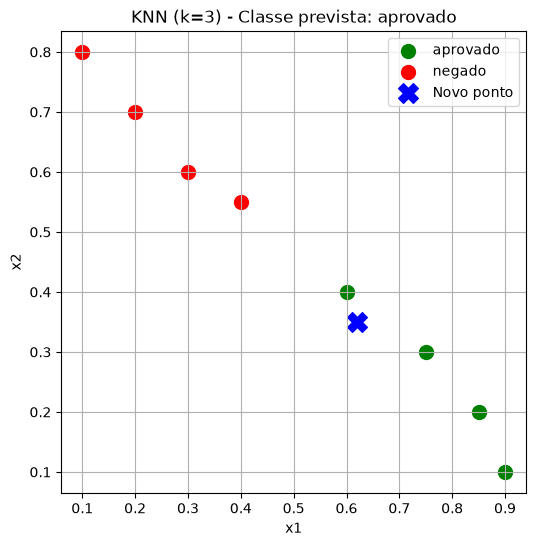

In [9]:
plt.figure(figsize=(6,6))

cores = {"aprovado": "green", "negado": "red"}
for classe_nome, grupo in df.groupby("classe"):
    plt.scatter(
        grupo["x1"], grupo["x2"],
        label=classe_nome,
        color=cores[classe_nome],
        s=100  # tamanho do marcador (aumentado para visualização em sala)
    )

plt.scatter(
    x_new[0], x_new[1],
    color="blue",
    marker="X",
    s=200,
    label="Novo ponto"
)
plt.title(f"KNN (k=3) - Classe prevista: {classe}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()

# Ensina Dev

In [11]:
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

In [12]:
dados = pd.DataFrame({
    "idade": [22, 25, 47, 52, 46, 56, 23, 60],
    "salario_mil": [2.5, 3.0, 8.0, 9.5, 7.8, 10.2, 2.8, 11.0],
    "comprou_plano_premium": [0, 0, 1, 1, 1, 1, 0, 1],
})

In [13]:
X = dados[["idade", "salario_mil"]]
y = dados["comprou_plano_premium"]

In [14]:
modelo = KNeighborsClassifier(n_neighbors=3)
modelo.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [15]:
novo_cliente = pd.DataFrame({"idade": [48], "salario_mil": [8.5]})

In [16]:
print(modelo.predict(novo_cliente))

[1]


O modelo previu que este novo cliente vai comprar o plano premium (representado pelo número 1).

In [17]:
print(modelo.predict_proba(novo_cliente))

[[0. 1.]]


Esta função retorna a probabilidade estimada para cada classe ([probabilidade da classe 0, probabilidade da classe 1]).

Como o resultado é [[0., 1.]], significa que 100% dos 3 vizinhos mais próximos (os 3 clientes mais parecidos com este em idade e salário) pertencem à classe 1. Não há nenhuma evidência (0%) de que ele pertença à classe 0 segundo os vizinhos mais próximos.